In [1]:
import numpy as np
import pandas as pd
import random
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report
from itertools import product
import statsmodels.api as sm

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

# file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
# file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
# file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'

# dataset1 = read_data(file1)
# dataset2 = read_data(file2)
# dataset3 = read_data(file3)
dataset4 = read_data(file4)


# dataset1.head()

# dataset2.head()

# dataset3.head()

dataset4.head()

# dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])
dataset = dataset4

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(1176, 112)


In [2]:
dataset.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL301,2010,1,23.825080,38.055971,0.249640,0.154335,-0.051484,-0.154335,0.254681,0.151875,-0.063238,-0.151875,0.038201,0.028667,0.031282,0.028667,13.766817,10.845785,11.665333,17.146430,17.146430,8.722301,5.512796,4.611190,6.437312,6.437312,11.244559,8.179290,8.138262,11.791871,11.791871,4.383333,17.155333,7.347749,23.337556,32.042954,227.170870,1236.463865,31.000000,1.000000,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.00000,21.863192,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,881.0,2990.0,0
1,EL302,2010,1,23.686502,38.024894,0.121799,0.075708,-0.046494,-0.075708,0.143216,0.084564,-0.051676,-0.084564,0.056306,0.024884,0.032559,0.024884,14.818000,11.446903,11.409714,18.024968,18.024968,10.888194,7.663290,6.765429,8.584452,8.584452,12.853097,9.555097,9.087571,13.304710,13.304710,7.018000,18.394000,7.394180,19.997378,29.097844,228.684803,1221.439881,31.000000,1.000000,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,1,9,1,13,13,10,8,9,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.00000,2.978368,39132.0,180473.0,33120.0,252725.0,36806.0,177964.0,43801.0,258571.0,7725.12,2236.0,2561.0,0
2,EL303,2010,1,23.757527,37.973503,0.146768,0.161544,0.060901,-0.161544,0.161503,0.148007,0.031014,-0.148007,0.061136,0.049947,0.054355,0.049947,14.646194,11.370194,11.357643,17.054194,17.054194,10.155161,7.744364,5.893857,7.908516,7.908516,12.400677,9.557279,8.625750,12.481355,12.481355,5.418000,18.374000,6.734685,29.146720,36.374201,208.524210,1181.441722,31.000000,1.000000,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,1,9,1,13,13,10,8,9,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.02

In [3]:
dataset = encode_cyclical(dataset, 'month', 12)

In [4]:
dataset.cases.sum()

296

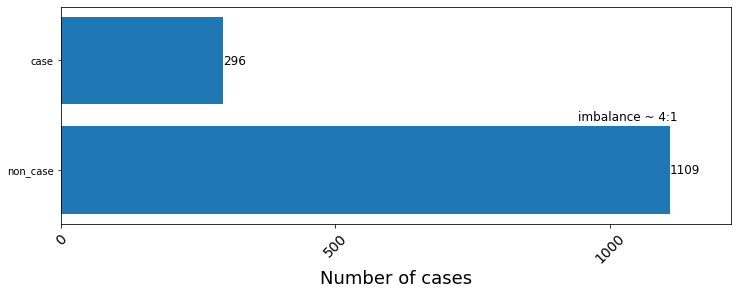

In [5]:
plot_imbalance(dataset, target_column='cases')

In [6]:
#dataset = dataset.query('month >= 5 & month <= 11')
dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

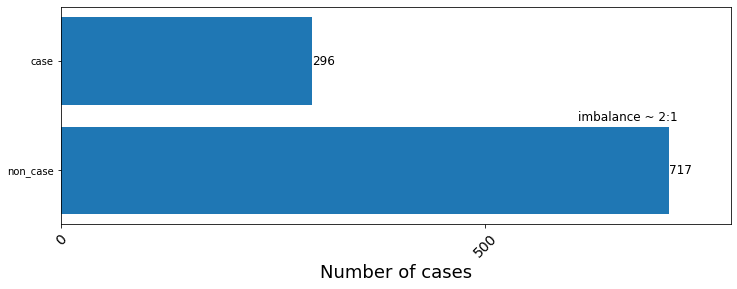

In [7]:
plot_imbalance(dataset, target_column='cases')

In [8]:
dataset.shape

(784, 114)

In [9]:
dataset.cases.sum()

296

In [10]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,56,0,56,inf%
1,2011,43,30,73,1.43%
2,2012,47,45,92,1.04%
3,2013,47,35,82,1.34%
4,2014,55,2,57,27.50%
5,2015,56,0,56,inf%
6,2016,56,0,56,inf%
7,2017,56,0,56,inf%
8,2018,31,155,186,0.20%
9,2019,51,24,75,2.12%


In [11]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [12]:
n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
#k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [13]:
features_to_remove = ['lst_jan_night_mean', 'males_gt65', 'flow_accu_200m', 'ndbi_mean',
       'ndbi', 'lst_apr_mean', 'lst_mean', 'l_total', 'fs_area_1km_max',
       'distance_to_coast_std', 'flow_accu_200m_max', 'distance_to_river_max',
       'hillshade_mean_1km_max', 'elevation_mean_1km_max',
       'aspect_mean_200m_max', 'distance_to_river_std', 'flow_accu_200m_std',
       'month_sin', 'slope_mean_1km_std', 'aspect_mean_200m_std',
       'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std',
       'females_lt15', 'unl_total', 'slope_mean_1km_max', 'ndbi_std',
       'distance_to_coast_max', 'flow_accu_200m_min', 'lst_mar_day_mean',
       'bio5', 'bio7', 'bio9', 'bio15', 'lc_prop1', 'lc_prop2', 'lc_prop3',
       'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'distance_to_coast_min',
       'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min',
       'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min',
       'lc_type2', 'lst_mar_mean']


features_to_remove = features_to_remove + ['x', 'y', 'year', 'month']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_jan_mean', 'lst_feb_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio6', 'bio8', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio16', 'bio17', 'bio18', 'bio19', 'fs_area_1km', 'males_lt15', 'males_15t64', 'males_total', 'females_15t64', 'females_gt65', 'females_total', 'mio_eur', 'month_cos']


In [14]:
print(f"Total Features Used: {len(feature_names)}")

Total Features Used: 52


In [15]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train = convert_multiple_cases(data_train, target_col='cases')
    #data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.1,
        "min_split_loss": 0.5,
        "max_depth": 3, 
        "reg_alpha": 0.5,
        "reg_lambda": 0.5,
        "min_child_weight": 1.5,
        "scale_pos_weight": sum_negatives/sum_positives, 
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(data_train['cases'].value_counts().get(0) / data_train['cases'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases'].value_counts().get(0) / data_test['cases'].value_counts().get(1)):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    #scaler = RobustScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/10
Training set 0/1 Ratio: 2.43
Test set 0/1 Ratio: 10.29
Weight: 2.43
Fold: 2/10
Training set 0/1 Ratio: 2.70
Test set 0/1 Ratio: 10.29
Weight: 2.70
Fold: 3/10
Training set 0/1 Ratio: 2.43
Test set 0/1 Ratio: 10.29
Weight: 2.43
Fold: 4/10
Training set 0/1 Ratio: 2.35
Test set 0/1 Ratio: 10.29
Weight: 2.35
Fold: 5/10
Training set 0/1 Ratio: 2.26
Test set 0/1 Ratio: 12.00
Weight: 2.26
Fold: 6/10
Training set 0/1 Ratio: 2.35
Test set 0/1 Ratio: 12.00
Weight: 2.35
Fold: 7/10
Training set 0/1 Ratio: 2.35
Test set 0/1 Ratio: 12.00
Weight: 2.35
Fold: 8/10
Training set 0/1 Ratio: 2.52
Test set 0/1 Ratio: 10.14
Weight: 2.52
Fold: 9/10
Training set 0/1 Ratio: 2.42
Test set 0/1 Ratio: 10.14
Weight: 2.42
Fold: 10/10
Training set 0/1 Ratio: 2.46
Test set 0/1 Ratio: 10.14
Weight: 2.46


In [16]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [17]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0351
Test Loss: 0.1446


In [18]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_train_proba[:,1], y_train_true, beta = 2, round_factor = 2)
print(classification_thresholds)

0.59


In [19]:
thr = classification_thresholds

In [20]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

In [21]:
print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       717
           1       0.72      0.66      0.69        67

    accuracy                           0.95       784
   macro avg       0.84      0.82      0.83       784
weighted avg       0.95      0.95      0.95       784



In [22]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[700  17]
 [ 23  44]]


In [23]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)


In [24]:
# Tree explainer

# curently not working with multioutput models

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

In [25]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Tree_Shapely_Values.npz'

# np.savez(shap_values_path, *tree_shap_values)

# # shap_values = []
# # loaded_shap_values = np.load(shap_values_path)

# # for key in loaded_shap_values.keys():
# #     shap_values.append(loaded_shap_values[key])

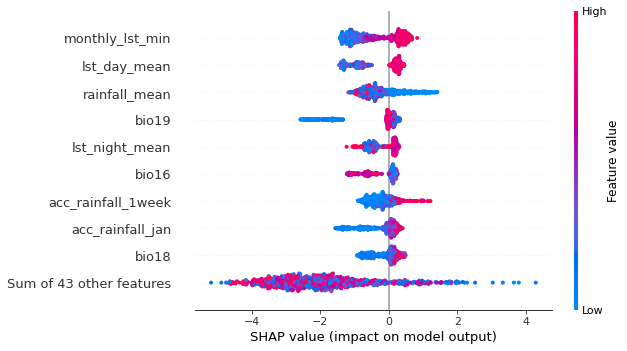

In [26]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=10)

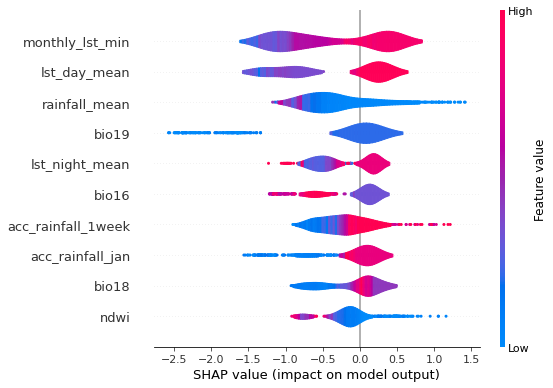

In [27]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin', max_display=10)

In [28]:
shap_lim = (-2.5, 1.5)

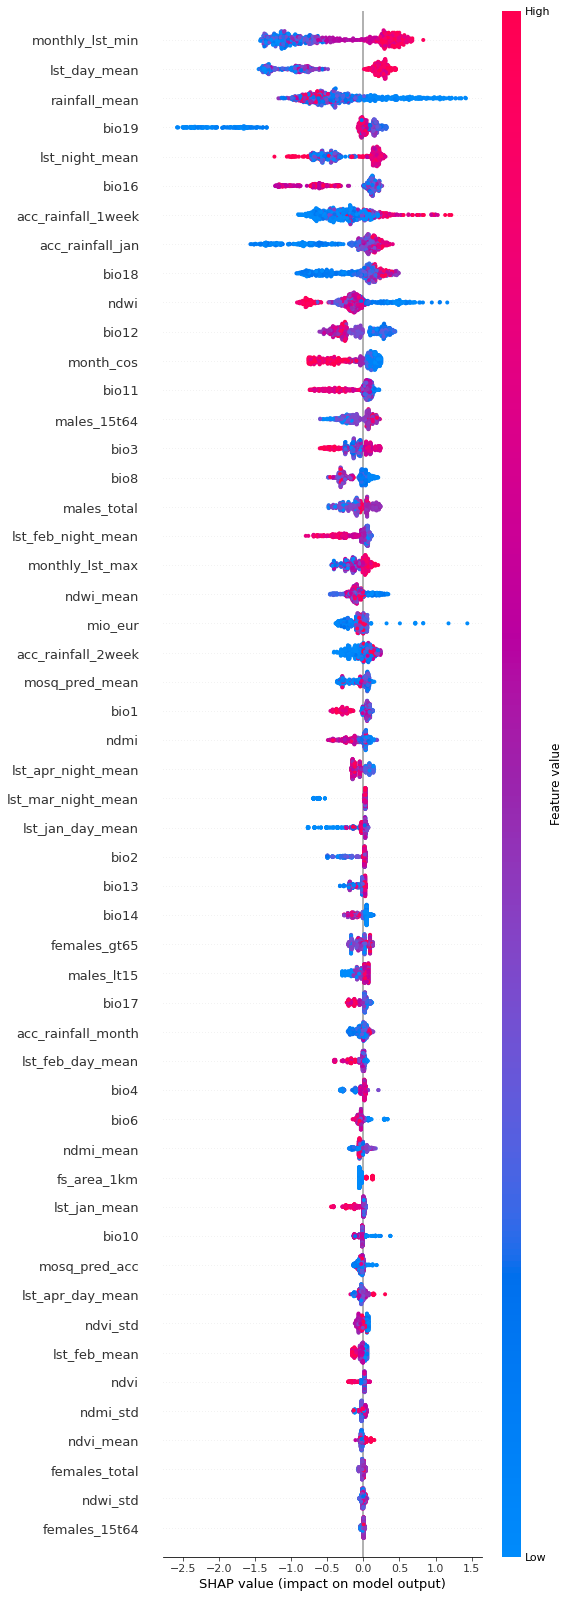

In [29]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=110)

In [30]:
#sorted_mean_abs_values_idx[-55:-1]

In [31]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']

In [32]:
tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

In [33]:
X_train

,ndvi,ndmi,ndwi,ndvi_mean,ndmi_mean,ndwi_mean,ndvi_std,ndmi_std,ndwi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_apr_day_mean,lst_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio6,bio8,bio10,bio11,bio12,bio13,bio14,bio16,bio17,bio18,bio19,fs_area_1km,males_lt15,males_15t64,males_total,females_15t64,females_gt65,females_total,mio_eur,month_cos
0,0.219903,0.074701,-0.169628,0.226367,0.074010,-0.177680,0.026201,0.018311,0.025492,23.262667,11.083892,13.458429,23.262667,11.501867,6.867143,9.693656,11.501867,8.382452,10.162786,8.218000,28.486000,0.386469,1.319145,4.807225,11.594069,321.899392,2305.200000,76.840000,19.000000,19.166667,42.592593,920.721061,0.0,8.333333,30.666667,8.333333,1230.0,227.0,9.0,546.0,54.0,54.0,546.0,0.000000,45632.0,201617.0,293201.0,220852.0,58521.0,322694.0,19823.63,-0.866025
1,0.115349,0.013643,-0.146415,0.130363,0.019350,-0.155175,0.026606,0.015838,0.027459,25.754133,13.873871,14.947857,25.754133,13.304800,7.362286,11.568710,13.304800,10.596452,11.155071,10.506000,31.970000,0.351680,2.062588,5.498179,10.550402,311.999466,3553.600000,118.453333,20.791667,18.916667,42.992424,928.453830,2.0,9.833333,33.000000,9.833333,1216.0,229.0,10.0,538.0,55.0,55.0,538.0,0.000000,39132.0,180473.0,252725.0,177964.0,43801.0,258571.0,7725.12,-0.866025
2,0.188953,0.056243,-0.149503,0.183489,0.063288,-0.136127,0.037569,0.025768,0.020876,24.471400,12.769548,14.133429,24.471400,12.967333,8.363143,10.884710,12.967333,9.811968,11.248286,9.916000,30.114000,0.322678,0.447345,3.239057,9.680333,313.017404,2883.400000,96.113333,19.875000,18.250000,43.452381,879.081390,2.0,9.833333,31.333333,9.833333,1175.0,208.0,5.0,521.0,47.0,47.0,521.0,0.000000,65801.0,384275.0,528902.0,394771.0,118140.0,575205.0,42230.54,-0.866025
3,0.162586,0.037892,-0.167944,0.151543,0.041835,-0.149931,0.015822,0.009027,0.016872,24.295714,12.655346,13.965204,24.295714,13.508190,8.893776,11.315346,13.508190,9.466083,11.429490,10.367143,30.024286,0.286555,0.771128,3.481473,8.596645,305.728358,3538.857143,117.961905,19.291667,18.250000,42.441860,874.761872,0.0,9.666667,30.666667,9.333333,1156.0,200.0,3.0,512.0,41.0,41.0,456.0,0.000000,39069.0,184842.0,264029.0,199704.0,54439.0,291026.0,13339.20,-0.866025
4,0.389746,0.117594,-0.279389,0.381624,0.116451,-0.271920,0.032704,0.029525,0.027087,23.555250,11.570365,13.267394,23.555250,9.734070,5.984052,8.466946,9.734070,8.679107,9.625723,7.364747,27.791616,0.392587,2.534419,5.228449,11.777624,324.559671,1925.390572,64.179686,18.708333,19.916667,44.259259,885.093301,0.0,9.000000,29.833333,8.333333,1231.0,223.0,7.0,539.0,47.0,47.0,467.0,0.004394,41876.0,176906.0,252569.0,167626.0,37127.0,244380.0,13475.35,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.571742,12.777786,18.078129,NaN,6.215929,9.757226,9.757226,10.856516,9.496857,10.983600,26.301771,NaN,0.000000,0.000000,0.000000,484.330368,3274.300000,109.143333,20.125000,20.083333,44.629630,878.822818,-1.0,11.166667,31.166667,9.833333,781.0,246.0,1.0,447.0,68.0,81.0,210.0,0.000000,58763.0,333312.0,479792.0,337392.0,128106.0,520156.0,27952.79,1.000000
780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.426959,13.127653,18.424470,NaN,6.615714,10.509355,10.509355,11.454977,9.871684,10.983600,26.301771,NaN,0.000000,0.000000,0.000000,465.277056,3739.857143,124.661905,20.041667,19.250000,42.777778,889.958715,-3.0,11.333333,30.666667,9.166667,752.0,243.0,0.0,462.0,44.0,52.0,216.0,0.000000,35733.0,163957.0,248890.0,177801.0,67623.0,279583.0,9362.51,1.000000
781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.890315,12.771768,17.413586,NaN,4.222393,7.57

In [34]:
tree_shap_values_df

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndvi_mean,ndmi_mean,ndwi_mean,ndvi_std,ndmi_std,ndwi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_apr_day_mean,lst_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio6,bio8,bio10,bio11,bio12,bio13,bio14,bio16,bio17,bio18,bio19,fs_area_1km,males_lt15,males_15t64,males_total,females_15t64,females_gt65,females_total,mio_eur,month_cos,cases
0,EL301,2010,5,23.825080,38.055971,0.025863,-0.168776,-0.245914,-0.023036,-0.041662,-0.076828,0.066230,-0.003429,-0.000401,-1.224028,0.026914,-0.060969,0.053982,-0.668370,0.007784,0.027485,-0.148510,0.001319,-0.048302,-0.797625,-0.202931,0.097021,-0.635104,-0.192749,0.050751,-0.934878,-0.040067,0.022543,0.029403,0.019075,-0.157877,-0.002833,-0.072197,0.047520,-0.060079,0.028245,-0.420375,-0.153708,-0.137481,0.110452,0.020984,-0.645135,-0.021209,-0.018425,0.033612,0.078921,0.069286,0.002909,-0.037616,0.017369,-0.063193,0.092962,0
1,EL302,2010,5,23.686502,38.024894,-0.031659,-0.000444,-0.820613,-0.013483,-0.050336,-0.162044,0.043126,0.000290,-0.030737,-1.162624,-0.035997,-0.021371,0.039249,-0.398514,-0.005748,0.024800,-0.148510,-0.172746,-0.048302,-0.681939,-0.145295,0.146195,-0.522632,-0.152664,0.031470,-0.853040,-0.050649,-0.261630,-0.191014,0.011596,-0.169546,-0.002833,-0.109358,-0.048537,-0.060079,-0.401299,-0.479298,-0.153708,-0.158070,0.099883,0.020984,-0.632511,-0.028140,-0.018425,0.028987,0.030029,-0.154527,0.004705,-0.001770,-0.034563,-0.323063,0.055645,0
2,EL303,2010,5,23.757527,37.973503,0.017279,-0.111112,-0.796518,-0.027292,-0.041662,-0.063778,-0.063661,-0.023629,-0.030737,-1.205519,-0.031982,-0.021371,0.026161,-0.422480,-0.634871,0.024468,-0.148510,0.001319,-0.047839,-0.690588,-0.277614,0.146339,-0.599718,-0.148675,-0.011778,-0.884663,-0.061916,0.014103,0.056135,-0.162578,-0.164270,-0.002833,-0.148061,-0.026200,-0.060079,-0.287836,-0.079982,-0.088856,-0.005733,0.115947,0.020984,-0.621361,-0.012858,-0.018425,0.019814,0.077049,-0.022632,0.002909,-0.022062,0.017369,-0.083752,0.037541,0
3,EL304,2010,5,23.745366,37.906427,0.015128,-0.018394,-0.257714,-0.017739,0.059338,-0.124152,0.066230,-0.119329,-0.000401,-1.224028,-0.025503,-0.009744,0.026161,-0.601642,-0.634871,0.024718,-0.148510,0.001319,-0.047839,-0.709465,-0.242493,-0.004335,-0.614723,-0.192749,-0.028303,-0.883433,-0.026417,-0.307261,0.056135,-0.302762,-0.156920,-0.002833,-0.076261,-0.026200,-0.060079,-0.006803,-0.085501,-0.088856,0.045525,0.118143,0.026771,-0.666529,0.127991,-0.018425,0.009067,0.077049,0.069286,0.004705,-0.003632,0.017369,-0.082186,0.078525,0
4,EL305,2010,5,23.886562,38.040564,-0.028053,-0.113867,-0.236301,0.011438,-0.006789,-0.103689,-0.068477,0.024267,-0.000401,-1.221388,0.026493,0.007196,0.053982,-0.474316,0.100659,0.027485,-0.148510,0.002062,0.048820,-0.726204,-0.122635,0.063162,-0.660640,-0.158784,0.031470,-0.805804,-0.042450,0.013259,0.062610,0.014451,-0.157877,-0.002833,-0.072197,-0.051631,-0.060079,0.059929,-0.471643,-0.155452,-0.137481,0.100960,0.022179,-0.591381,0.127273,0.041685,0.018240,-0.107769,-0.121077,-0.006004,-0.005773,-0.034563,-0.063779,0.102611,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,EL303,2023,12,23.757527,37.973503,0.014638,-0.124209,-0.187139,0.001511,0.004734,-0.068420,-0.065663,-0.027421,0.026426,0.189367,-0.038297,-0.002839,-0.027132,-0.487493,0.074294,0.017076,-0.128734,-0.254269,0.053374,-0.548156,-0.142608,-0.569430,-0.326013,-0.236929,-0.004246,-0.821498,-0.028585,-0.035946,0.012188,0.005160,-0.219445,-0.004724,-0.004632,-0.354498,-0.062063,-0.496463,0.144179,-0.015426,0.079336,0.086205,0.023384,-0.068709,-2.233636,-0.05652

In [35]:
sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx

Index(['monthly_lst_min', 'lst_day_mean', 'rainfall_mean', 'bio19',
       'lst_night_mean', 'bio16', 'acc_rainfall_1week', 'acc_rainfall_jan',
       'bio18', 'ndwi', 'bio12', 'month_cos', 'bio11', 'males_15t64', 'bio3',
       'bio8', 'males_total', 'lst_feb_night_mean', 'monthly_lst_max',
       'ndwi_mean', 'mio_eur', 'acc_rainfall_2week', 'mosq_pred_mean', 'bio1',
       'ndmi', 'lst_apr_night_mean', 'lst_mar_night_mean', 'lst_jan_day_mean',
       'bio2', 'bio13', 'bio14', 'females_gt65', 'males_lt15', 'bio17',
       'acc_rainfall_month', 'lst_feb_day_mean', 'bio4', 'bio6', 'ndmi_mean',
       'fs_area_1km', 'lst_jan_mean', 'bio10', 'mosq_pred_acc',
       'lst_apr_day_mean', 'ndvi_std', 'lst_feb_mean', 'ndvi', 'ndmi_std',
       'ndvi_mean', 'females_total', 'ndwi_std', 'females_15t64'],
      dtype='object')

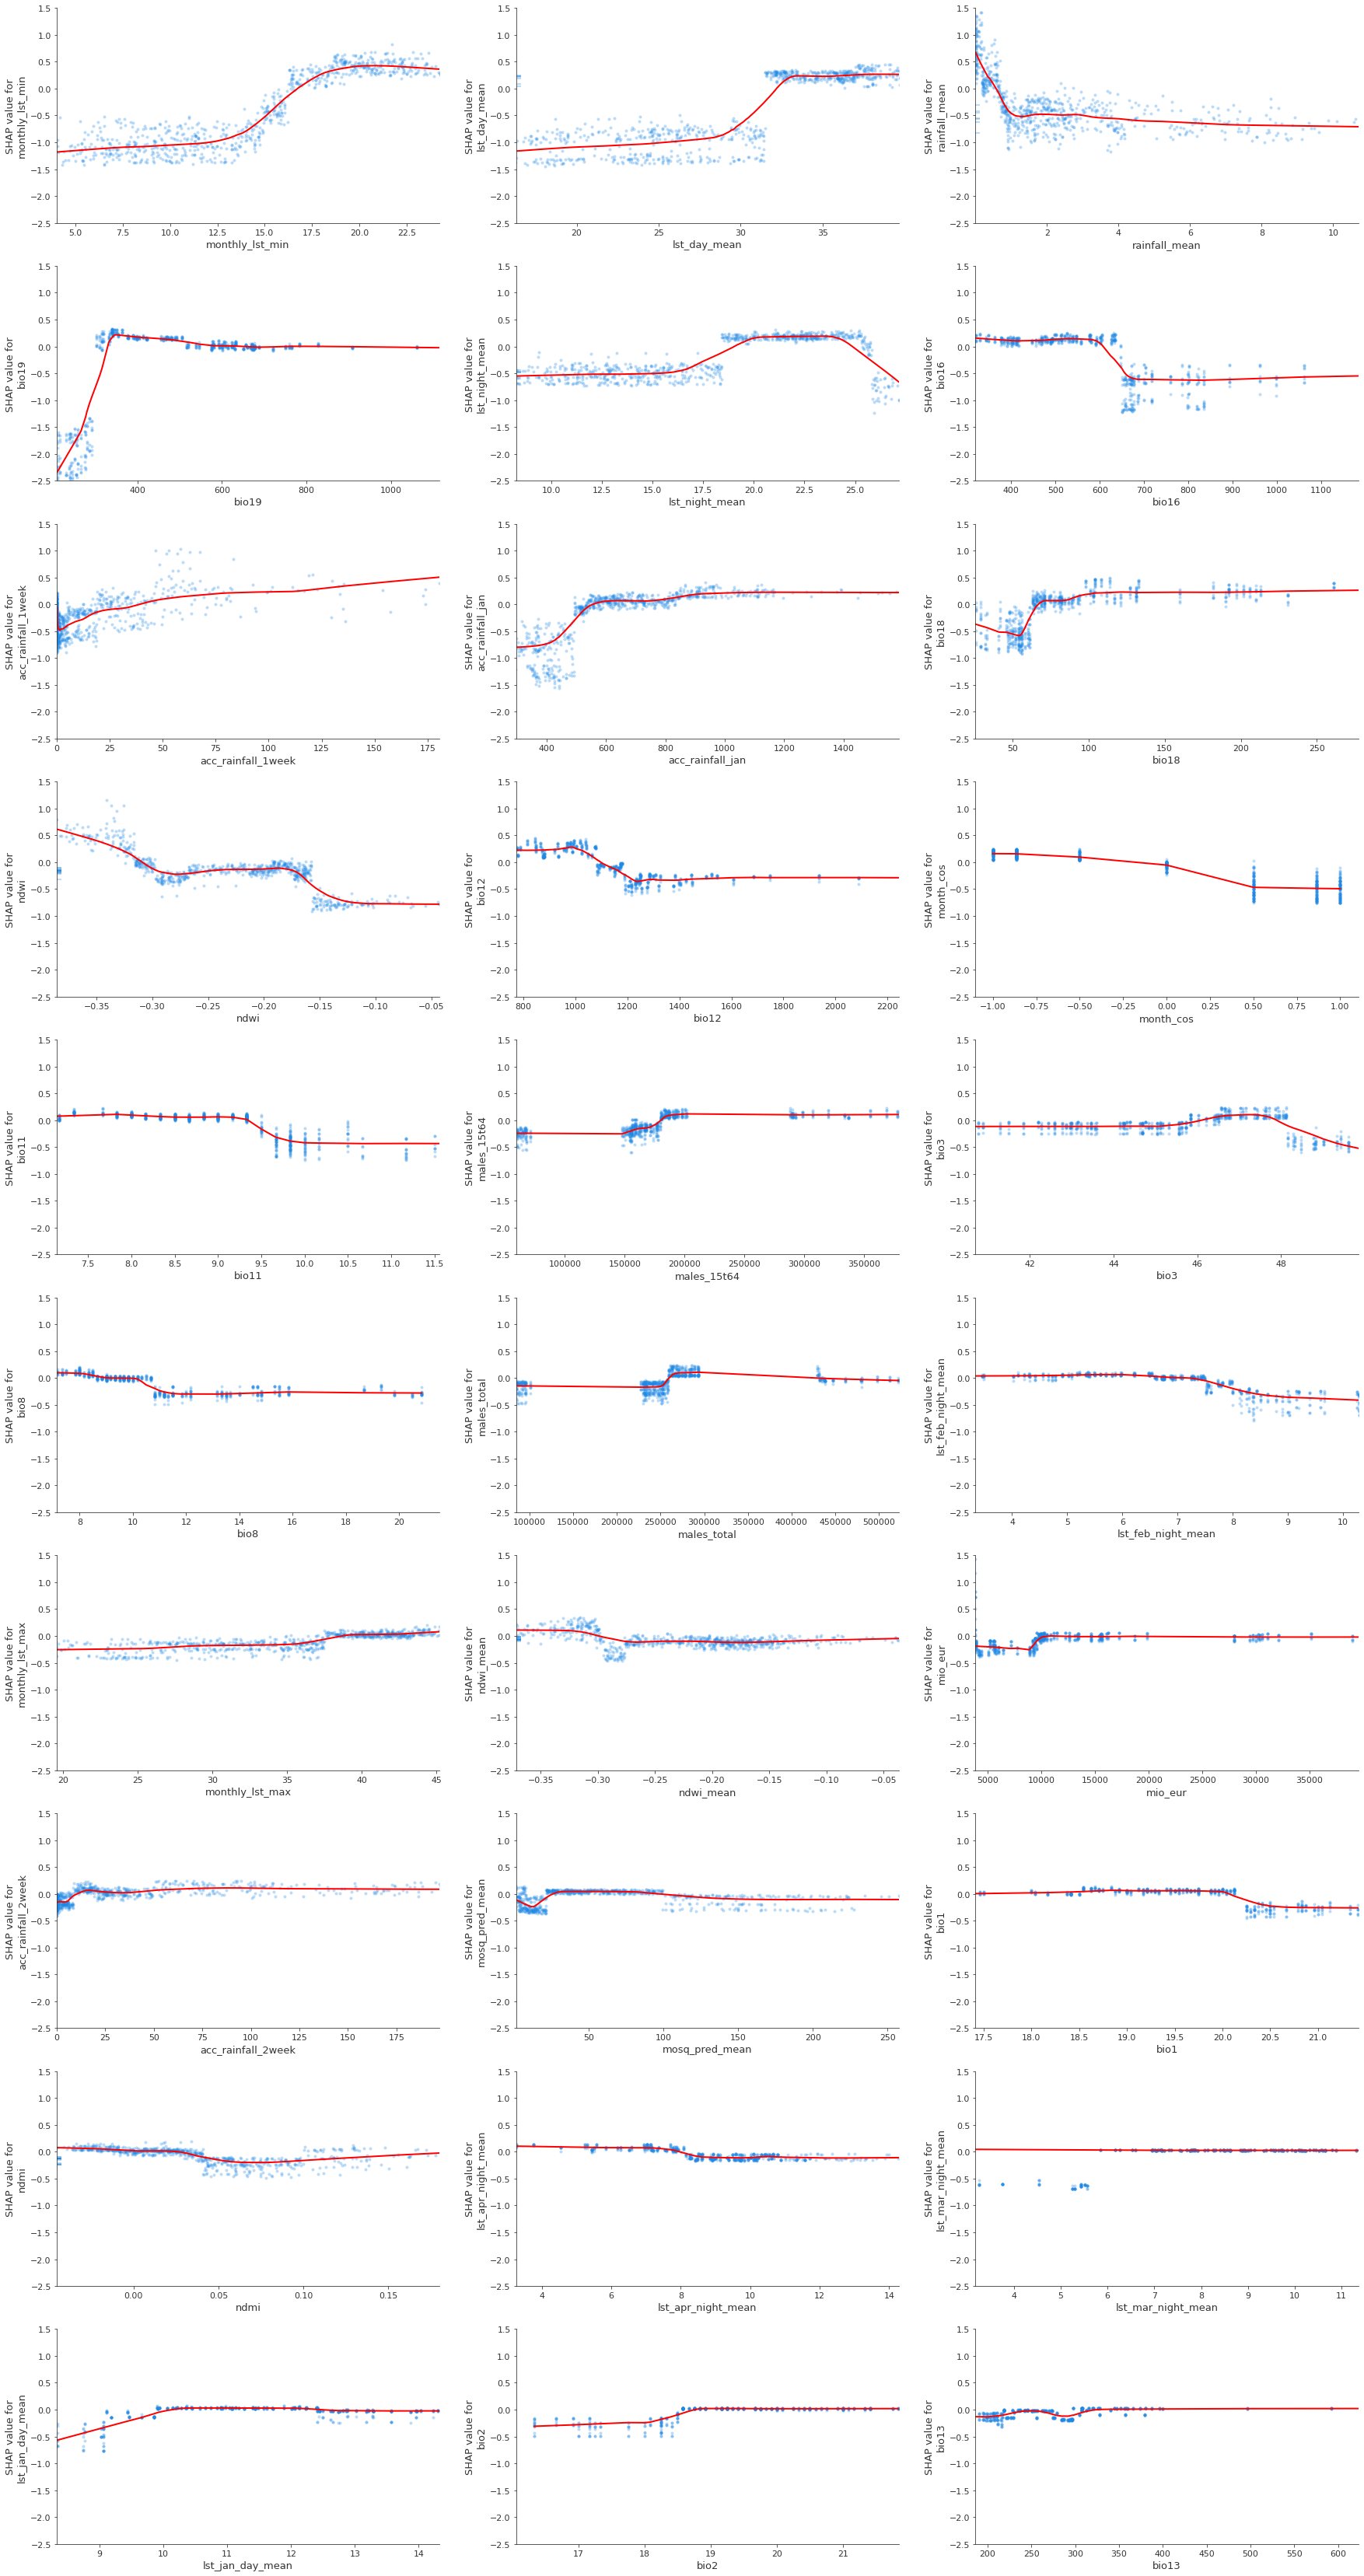

In [36]:
num_plots = 30

fig, axes = plt.subplots(10, 3, figsize=(30, 60))  # Adjust figsize as needed
i = 0

for ft in sorted_mean_abs_values_idx[:num_plots]:
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2, frac=.3)
    
    ax.plot(*list(zip(*lowess)), color="red", lw=2)
    ax.set_ylim(shap_lim)

    # for tick in ax.get_xticklabels():
    #     tick.set_rotation(60)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values, features=X_train, 
                         feature_names=feature_names, interaction_index=None, 
                         xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax=ax, show = False)
    
    i = i+1

plt.show()

    

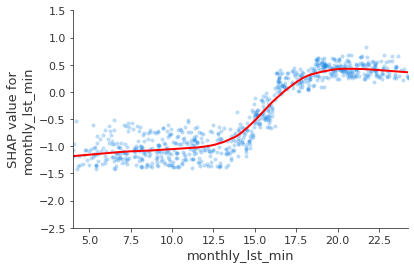

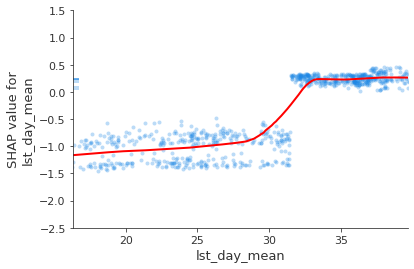

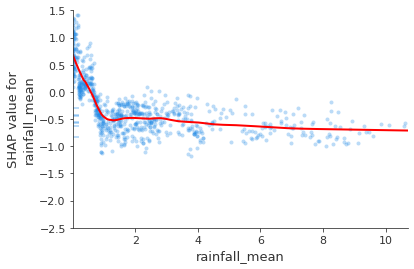

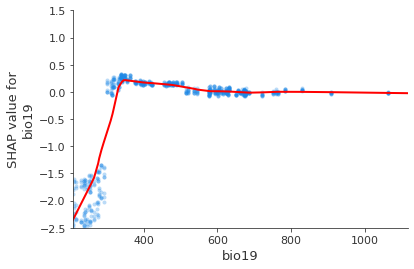

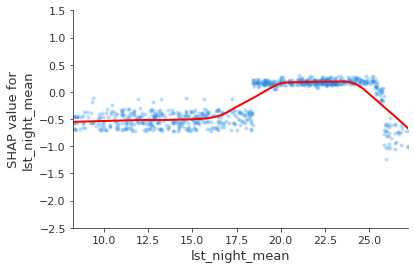

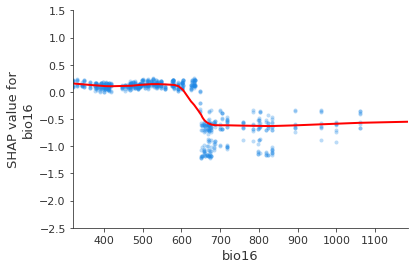

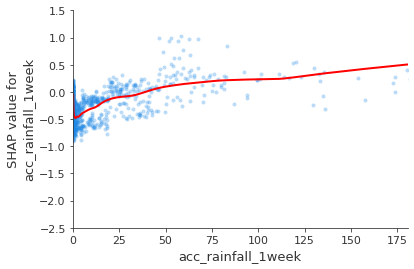

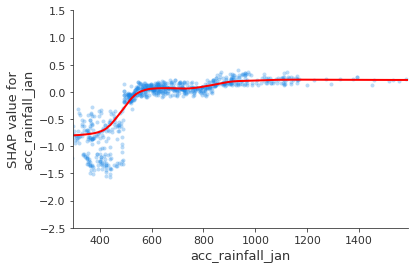

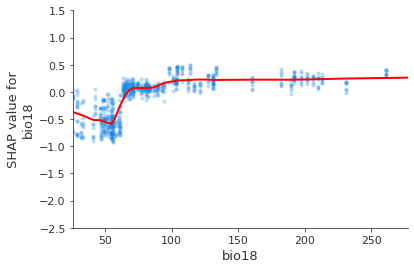

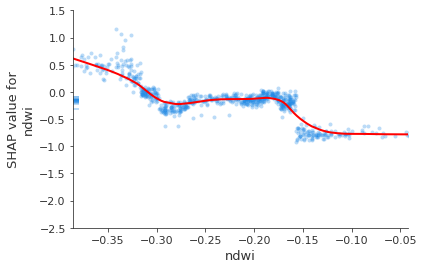

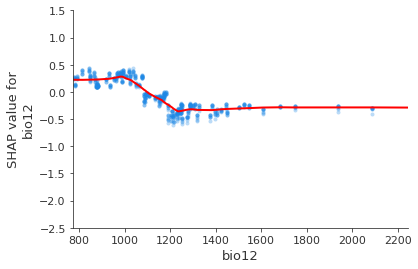

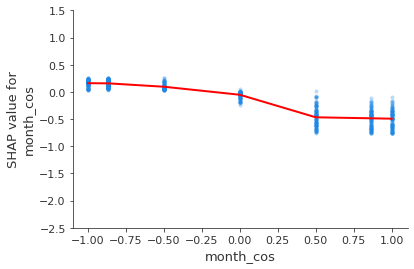

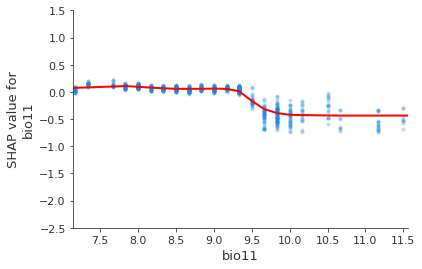

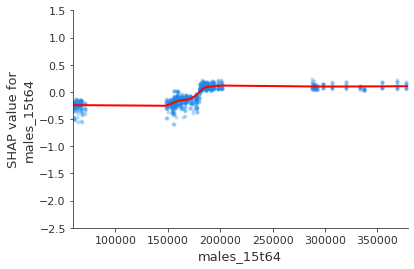

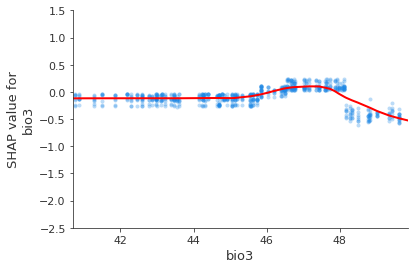

In [37]:
for ft in sorted_mean_abs_values_idx[:15]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)